## Monte Carlo Simulation
### Import Modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import random

random.seed(412)

# Ex1: Rolling two dice and getting 6 for both!
def estimate_double_six(n_trials=100000):
    count_double_six = 0
    for _ in range(n_trials):
        die1 = random.randint(1, 6)
        die2 = random.randint(1, 6)
        if die1 == 6 and die2 == 6:
            count_double_six += 1
    probability = count_double_six / n_trials
    return probability

# Run the simulation with 100,000 trials
est_prob = estimate_double_six(100000) * 100
print(f"Estimate P(double six) = {est_prob:.3f}%")

Estimate P(double six) = 2.724%


In [3]:
# Run the simulation with 1,000,000 trials
est_prob = estimate_double_six(1000000) * 100
print(f"Estimate P(double six) = {est_prob:.3f}%")

Estimate P(double six) = 2.753%


In [4]:
import math

random.seed(42)

# Ex2: Estimate pie by randomly sampling points in a square
def estimate_pi(n_samples):
    inside_count = 0
    for _ in range(n_samples):
        x = random.random()
        y = random.random()
        if x*x + y*y <= 1.0:
            inside_count += 1
    return 4 * inside_count / n_samples

In [5]:
# Estimate pi with increasing sample sizes
for N in [1000, 10000, 100000, 1000000]:
    pi_est = estimate_pi(N)
    print(f"N={N:<8} -> pi_est = {pi_est:.5f}, error = {abs(pi_est - math.pi):.5f}")

N=1000     -> pi_est = 3.12800, error = 0.01359
N=10000    -> pi_est = 3.12880, error = 0.01279
N=100000   -> pi_est = 3.13988, error = 0.00171
N=1000000  -> pi_est = 3.14056, error = 0.00103


In [6]:
random.seed(42)

# Ex3: Distribution of Sums of Two Dices
# def estimate_sumdice(n_trials):
#     sum_count = 0
#     for _ in range(n_trials):
#         die1 = random.randint(1, 7, size=N)
#         die2 = random.randint(1, 7, size=N)
#         if die1 + die2 = :
#             sum_count += 1
#     return sum_count / n_trials

N = 100_00

die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)

sums = die1 + die2

print("First 10 simulated sums:", sums[:10])

First 10 simulated sums: [11  6  9 10  4  9  6  4  7  6]


In [7]:
from collections import Counter

# Compute empirical freq of each sum
counts = Counter(sums)

# Calculate empirical probability of each possible sum (2 to 12)
possible_sums = list(range(2, 13))
empirical_probs = [counts[sum_val] / N for sum_val in possible_sums]

# Compute theoretical prob for each sum (2 to 12)
theoretical_counts = [(s-1) if s <= 7 else (13-s) for s in possible_sums]
theoretical_probs = [count/36.0 for count in theoretical_counts]

# Display quick comparison of empirical vs theoretical probs for sums 2 through 12
for s, emp, theo in zip(possible_sums, empirical_probs, theoretical_probs):
    print(f"Sum {s:>2}: Empirical = {emp:.4f}, Theoretical = {theo:.4f}")

Sum  2: Empirical = 0.0287, Theoretical = 0.0278
Sum  3: Empirical = 0.0556, Theoretical = 0.0556
Sum  4: Empirical = 0.0830, Theoretical = 0.0833
Sum  5: Empirical = 0.1108, Theoretical = 0.1111
Sum  6: Empirical = 0.1435, Theoretical = 0.1389
Sum  7: Empirical = 0.1662, Theoretical = 0.1667
Sum  8: Empirical = 0.1414, Theoretical = 0.1389
Sum  9: Empirical = 0.1070, Theoretical = 0.1111
Sum 10: Empirical = 0.0818, Theoretical = 0.0833
Sum 11: Empirical = 0.0534, Theoretical = 0.0556
Sum 12: Empirical = 0.0286, Theoretical = 0.0278


In [8]:
sns.set_style("whitegrid")

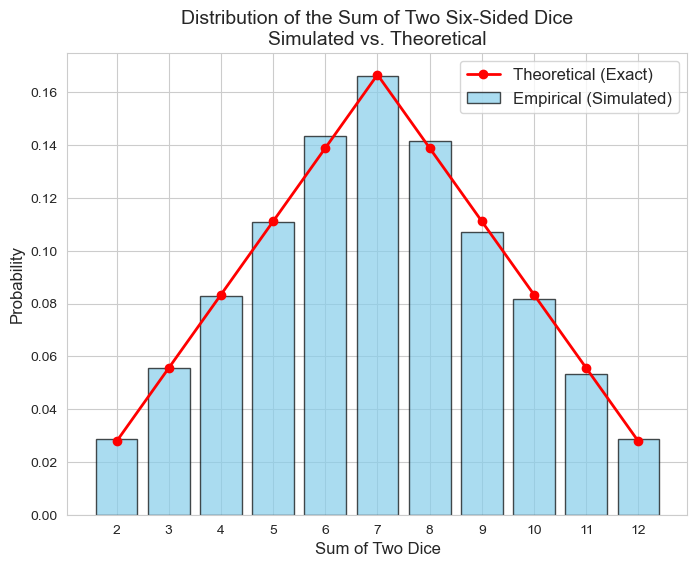

In [9]:
plt.figure(figsize=(8,6))
plt.bar(possible_sums, empirical_probs,
        color="skyblue", edgecolor="black", width=0.8, alpha=0.7, label="Empirical (Simulated)")

plt.plot(possible_sums, theoretical_probs,
         color="red", marker="o", linestyle="-", linewidth=2, markersize=6, label="Theoretical (Exact)")

plt.title("Distribution of the Sum of Two Six-Sided Dice\nSimulated vs. Theoretical", fontsize=14)
plt.xlabel("Sum of Two Dice", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.xticks(possible_sums)
plt.legend(fontsize=12)
plt.show()

In [10]:
import random
from math import comb

# Case Study: Powerball Lottery Odds
def play_powerball(winning_whites, winning_powerball):
    # Simulate a random ticket (5 distinct white balls + 1 red)
    ticket_whites = set(random.sample(range(1, 70), 5))
    ticket_powerball = random.randint(1, 26)
    # Count matches
    white_matches = len(ticket_whites & winning_whites)
    powerball_match = (ticket_powerball == winning_powerball)
    return white_matches, powerball_match

In [11]:
# Run Monte Carlo simulation for Powerball Outcomes
N = 1000000

# Bonus points: increase this number to see how the empirical probs change
# Warning: When n = 1M takes a few seconds to execute, anything more will take much longer
# You can verify that it is still exectuing by the *

# First, generate a winning number
winning_whites = set(random.sample(range(1, 70), 5))
winning_powerball = random.randint(1, 26)

# Initialize counters for each category of interest
outcomes = {
    "5+1 (Jackpot)": 0,
    "5+0":0,
    "4+1":0,
    "4+0":0,
    "3+1":0,
    "3+0":0,
    "2+1":0,
    "1+1":0,
    "0+1":0,
    "No Win":0
}

In [12]:
for _ in range(N):
    w_matches, pb_match = play_powerball(winning_whites, winning_powerball)
    if w_matches == 5 and pb_match:
        outcomes["5+1 (Jackpot)"] += 1
    elif w_matches == 5 and not pb_match:
        outcomes["5+0"] += 1
    elif w_matches == 4 and pb_match:
        outcomes["4+1"] += 1
    elif w_matches == 4 and not pb_match:
        outcomes["4+0"] += 1
    elif w_matches == 3 and pb_match:
        outcomes["3+1"] += 1
    elif w_matches == 3 and not pb_match:
        outcomes["3+0"] += 1
    elif w_matches == 2 and pb_match:
        outcomes["2+1"] += 1
    elif w_matches == 1 and pb_match:
        outcomes["1+1"] += 1
    elif w_matches == 0 and pb_match:
        outcomes["0+1"] += 1
    else:
        outcomes["No Win"] += 1

In [13]:
# Convert counts to probs
print(f"N={N}")
for category, count in outcomes.items():
    print(f"{category:14s}: {count}, {count/N:.12f} (approx 1 in {N/count if count>0 else 'infinity'})")

N=1000000
5+1 (Jackpot) : 0, 0.000000000000 (approx 1 in infinity)
5+0           : 0, 0.000000000000 (approx 1 in infinity)
4+1           : 1, 0.000001000000 (approx 1 in 1000000.0)
4+0           : 30, 0.000030000000 (approx 1 in 33333.333333333336)
3+1           : 77, 0.000077000000 (approx 1 in 12987.012987012988)
3+0           : 1786, 0.001786000000 (approx 1 in 559.9104143337066)
2+1           : 1420, 0.001420000000 (approx 1 in 704.2253521126761)
1+1           : 10831, 0.010831000000 (approx 1 in 92.32757824762257)
0+1           : 25770, 0.025770000000 (approx 1 in 38.80481179666278)
No Win        : 960085, 0.960085000000 (approx 1 in 1.0415744439294436)


In [14]:
for N in [1000, 10000, 100000, 1000000, 10000000, 100000000]:
    pi_est = estimate_pi(N)
    print(f"N={N:<9} -> pi_est = {pi_est:.5f}, error = {abs(pi_est - math.pi):.5f}")

N=1000      -> pi_est = 3.10800, error = 0.03359
N=10000     -> pi_est = 3.11480, error = 0.02679
N=100000    -> pi_est = 3.13124, error = 0.01035
N=1000000   -> pi_est = 3.14326, error = 0.00167
N=10000000  -> pi_est = 3.14086, error = 0.00073
N=100000000 -> pi_est = 3.14145, error = 0.00014


### Monte Carlo Simulation Project

In [15]:
import numpy as np
import random
from collections import Counter

In [16]:
np.random.seed(42) ## for reproducibility

In [21]:
# # Probability of throwing 3 fair six-sided dice that sum up to exactly 6
# def three_dice_sum6(n_trials):
#     sum6_count = 0
#     for _ in range(n_trials):
#         np.random.seed(42)
#         die1 = random.randint(1, 6)
#         die2 = random.randint(1, 6)
#         die3 = random.randint(1, 6)
#         sum = die1 + die2 + die3
#         if sum == 6:
#             sum6_count += 1
            
#     return sum6_count/n_trials

In [37]:
# 1000 samples
N = 1_000
np.random.seed(42)
die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)
die3 = np.random.randint(1, 7, size=N)

sums = die1 + die2 + die3

counts = Counter(sums)

# Calculate empirical prob for 3 dice that add up to 6
emp_prob = counts[6]/N
emp_prob

0.043

In [38]:
# 10,000 samples
N = 10_000
np.random.seed(42)
die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)
die3 = np.random.randint(1, 7, size=N)

sums = die1 + die2 + die3

counts = Counter(sums)

# Calculate empirical prob for 3 dice that add up to 6
emp_prob = counts[6]/N
emp_prob

0.0477

In [40]:
# 100,000 samples
N = 100_000
np.random.seed(42)
die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)
die3 = np.random.randint(1, 7, size=N)

sums = die1 + die2 + die3

counts = Counter(sums)

# Calculate empirical prob for 3 dice that add up to 6
emp_prob = counts[6]/N
emp_prob

0.04558

In [42]:
# 1,000,000 samples
N = 1_000_000
np.random.seed(42)
die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)
die3 = np.random.randint(1, 7, size=N)

sums = die1 + die2 + die3

counts = Counter(sums)

# Calculate empirical prob for 3 dice that add up to 6
emp_prob = counts[6]/N
emp_prob

0.046188

In [43]:
# 10,000,000 samples
N = 10_000_000
np.random.seed(42)
die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)
die3 = np.random.randint(1, 7, size=N)

sums = die1 + die2 + die3

counts = Counter(sums)

# Calculate empirical prob for 3 dice that add up to 6
emp_prob = counts[6]/N
emp_prob

0.0463232